# Modelowanie predykcji intensywności treningu (kcal/min)

Notebook obejmuje etap modelowania predykcyjnego na zbiorze `df_model` przygotowanym w Notebooku 01. Dane zostały wcześniej oczyszczone i przetworzone, dlatego analiza koncentruje się wyłącznie na budowie i ocenie modeli regresyjnych.

Zakres prac obejmuje:
- podział danych na zbiór treningowy i testowy,
- budowę naiwnego modelu bazowego (DummyRegressor), modelu referencyjnego (Linear Regression) oraz modelu docelowego (Random Forest Regressor wraz ze strojeniem hiperparapetrów),
- ocenę jakości modeli z wykorzystaniem walidacji krzyżowej i niezależnego zbioru testowego,
- analizę istotności cech,
- analizę błędów,
- zapis wytrenowanego modelu,
- krótki opis wykorzystania i wnioski.

# Import bibliotek i konfiguracja środowiska

W pierwszym kroku zaimportowano biblioteki niezbędne do przetwarzania danych, budowy modeli regresyjnych oraz ich ewaluacji.

Dodatkowo ustawiono parametry wyświetlania danych oraz styl wykresów, aby zachować spójność wizualną z Notebookiem 01 i ułatwić interpretację wyników.

Ustalono również stały RANDOM_STATE = 42 w celu zapewnienia powtarzalności wyników.

In [1]:
# Biblioteki bazowe
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Sklearn – modele, pipeline’y, preprocessing, walidacja, metryki
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

# Ustawienia wizualizacji i wyświetlania
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

# Wyświetlanie Markdown w notebooku via Code
from IPython.display import Markdown, display

# Powtarzalność 
import random 
RANDOM_STATE = 42 
np.random.seed(RANDOM_STATE) 
random.seed(RANDOM_STATE)

# Wczytanie przygotowanego zbioru danych

Wczytano finalny zbiór danych `activities_model_ready.parquet`, przygotowany w *Notebooku 01*.

Zbiór zawiera cechy numeryczne i kategoryczne o jednoznacznej interpretacji semantycznej oraz nie wymaga dodatkowego czyszczenia poza transformacjami realizowanymi w pipeline’ach modeli.

In [2]:
# Wczytanie przygotowanego zbioru danych
df = pd.read_parquet('../data/processed/activities_model_ready.parquet')

# Podstawowa charakterystyka zbioru
N, M = df.shape
display(Markdown(
    f"Zbiór danych obejmuje **{N} obserwacji** oraz **{M} zmiennych** i został utworzony "
    "na podstawie danych surowych zawierających **1340 obserwacji** oraz **34 zmienne**, "
    "wyeksportowanych z platformy Garmin Connect."
))

# Podgląd pierwszych obserwacji
df.head()

Zbiór danych obejmuje **1270 obserwacji** oraz **13 zmiennych** i został utworzony na podstawie danych surowych zawierających **1340 obserwacji** oraz **34 zmienne**, wyeksportowanych z platformy Garmin Connect.

,Activity Type,Distance,Avg HR,Max HR,Steps,Total Reps,Total Poses,Stress Change,Avg Stress,day_of_week,hour_sin,hour_cos,calories_per_min
0,Yoga,NaN,92,136,NaN,NaN,NaN,-18.0,74.0,5,-9.659258e-01,0.258819,3.996920
1,Cardio,NaN,145,179,NaN,NaN,NaN,NaN,NaN,4,-8.660254e-01,-0.500000,10.354052
2,Cardio,NaN,148,196,NaN,NaN,NaN,NaN,NaN,3,-9.659258e-01,0.258819,11.142658
3,Strength Training,NaN,89,113,NaN,5.0,1.0,NaN,NaN,2,-8.660254e-01,0.500000,3.863574
4,Yoga,NaN,102,119,NaN,NaN,NaN,90.0,88.0,2,1.224647e-16,-1.000000,5.198330


# Sanity checks – weryfikacja spójności zbioru danych przed modelowaniem

Przed budową modeli przeprowadzono podstawową weryfikację spójności zbioru danych. Sprawdzono obecność zmiennej docelowej `calories_per_min`, kompletność jej wartości oraz zgodność typów danych z założeniami przyjętymi w *Notebooku 01*.

Zmienna docelowa została pozostawiona w oryginalnej skali (`kcal/min`), co zapewnia bezpośrednią interpretowalność wyników.

In [3]:
# Kontrola obecności zmiennej docelowej
if 'calories_per_min' in df.columns:
    display(Markdown("Zmienna docelowa `calories_per_min` znajduje się w zbiorze danych."))
else:
    display(Markdown("Brak zmiennej docelowej `calories_per_min` w zbiorze danych."))

# Kontrola kompletności zmiennej docelowej
missing_target = df['calories_per_min'].isna().sum()
display(Markdown(f"Liczba brakujących wartości w zmiennej docelowej: {missing_target}"))

# Opis statystyczny zmiennej docelowej
display(Markdown("##### Statystyki opisowe zmiennej docelowej"))
display(df['calories_per_min'].describe())

# Struktura typów danych
display(Markdown("##### Struktura typów danych w zbiorze"))
display(df.dtypes.value_counts())

Zmienna docelowa `calories_per_min` znajduje się w zbiorze danych.

Liczba brakujących wartości w zmiennej docelowej: 0

##### Statystyki opisowe zmiennej docelowej

count    1270.000000
mean        6.109272
std         2.817879
min         0.093216
25%         4.225688
50%         5.148475
75%         6.694066
max        14.646244
Name: calories_per_min, dtype: float64

##### Struktura typów danych w zbiorze

float64    9
int64      2
str        1
int32      1
Name: count, dtype: int64

# Definicja zmiennej docelowej (target) i cech wejściowych (features)

**Zmienną docelową (target)** modelu jest intensywność treningu wyrażona jako liczba spalonych kalorii na minutę (`calories_per_min`), obliczona w *Notebooku 01*. 

**Cechy wejściowe (features)** stanowią pozostałe kolumny zbioru.

In [4]:
TARGET = 'calories_per_min'

# Podział na cechy wejściowe (X) i zmienną docelową (y)
X = df.drop(columns=TARGET).copy()
y = df[TARGET].copy()

print(f"Liczba obserwacji: {X.shape[0]}")
print(f"Liczba cech: {X.shape[1]}")

X.head()

Liczba obserwacji: 1270
Liczba cech: 12


,Activity Type,Distance,Avg HR,Max HR,Steps,Total Reps,Total Poses,Stress Change,Avg Stress,day_of_week,hour_sin,hour_cos
0,Yoga,NaN,92,136,NaN,NaN,NaN,-18.0,74.0,5,-9.659258e-01,0.258819
1,Cardio,NaN,145,179,NaN,NaN,NaN,NaN,NaN,4,-8.660254e-01,-0.500000
2,Cardio,NaN,148,196,NaN,NaN,NaN,NaN,NaN,3,-9.659258e-01,0.258819
3,Strength Training,NaN,89,113,NaN,5.0,1.0,NaN,NaN,2,-8.660254e-01,0.500000
4,Yoga,NaN,102,119,NaN,NaN,NaN,90.0,88.0,2,1.224647e-16,-1.000000


# Podział cech na numeryczne i kategoryczne

W celu zastosowania odpowiednich transformacji w pipeline’ach modeli podzielono cechy wejściowe na **kategoryczną** i **numeryczne**.

In [5]:
# Cecha kategoryczna
categorical_features = ['Activity Type']

# Cechy numeryczne
numeric_features = [
    col for col in X.columns
    if col not in categorical_features
]
print('Cecha kategoryczna:', categorical_features)
print('Cechy numeryczne:', numeric_features)

Cecha kategoryczna: ['Activity Type']
Cechy numeryczne: ['Distance', 'Avg HR', 'Max HR', 'Steps', 'Total Reps', 'Total Poses', 'Stress Change', 'Avg Stress', 'day_of_week', 'hour_sin', 'hour_cos']


# Preprocessing dla modelu drzewiastego

W celu przygotowania danych do trenowania modeli drzewiastych zastosowano `Pipeline` oraz `ColumnTransformer`, co zapewnia dopasowanie transformacji wyłącznie na zbiorze treningowym i eliminuje ryzyko wycieku informacji.

Zastosowane transformacje:
- **cechy numeryczne:** imputacja medianą,
- **cecha kategoryczna:** imputacja stałą wartością `missing` + one‑hot encoding.

In [6]:
# Transformer numeryczny: imputacja medianą
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Transformer kategoryczny: imputacja stałą wartością + one-hot encoding
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Preprocessor dla modelu drzewiastego
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numeric_features),
        ('cat', cat_transformer, categorical_features)
    ],
    remainder='drop'
)

# Preprocessing dla regresji liniowej (ze skalowaniem)

W regresji liniowej zastosowano imputację medianą oraz standaryzację (`StandardScaler`) **cech numerycznych** — modele liniowe są wrażliwe na skalę zmiennych, dlatego standaryzacja stabilizuje proces optymalizacji i ułatwia interpretację współczynników.

**Cecha kategoryczna** przetwarzana jest identycznie jak w modelu drzewiastym (imputacja stałą wartością `missing` + one-hot encoding).

In [7]:
# Transformer numeryczny dla regresji liniowej: imputacja medianą + skalowanie
num_transformer_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessor dla regresji liniowej
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', num_transformer_lr, numeric_features),
        ('cat', cat_transformer, categorical_features)
    ],
    remainder='drop'
)

# Podział danych na zbiór treningowy i testowy

Dane zostały podzielone na zbiór **treningowy (80%)** oraz **testowy (20%)**.

Zastosowano **stratyfikację względem zmiennej `Activity Type`**, aby zachować takie same proporcje typów aktywności w obu zbiorach.

In [8]:
stratify_col = X['Activity Type']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_col
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (1016, 12)
Test shape: (254, 12)


# Model bazowy: DummyRegressor (naive baseline)

Jako punkt odniesienia zastosowano model bazowy `DummyRegressor` z strategią `median`, który przewiduje stałą wartość równą medianie zmiennej docelowej `calories_per_min` w zbiorze treningowym.  

Model ten nie uczy się żadnych zależności pomiędzy cechami a zmienną docelową i pełni wyłącznie rolę **baseline’u**, stanowiąc dolną granicę jakości, którą powinny przekroczyć modele uczące się struktury danych.

In [9]:
# Baseline pipeline (używa tego samego preprocessora co model drzewiasty)
dummy_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('model', DummyRegressor(strategy='median'))
])

dummy_pipeline.fit(X_train, y_train)
y_pred_dummy = dummy_pipeline.predict(X_test)

mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
r2_dummy = r2_score(y_test, y_pred_dummy)

print(f"DummyRegressor – MAE (test): {mae_dummy:.4f}")
print(f"DummyRegressor – R²  (test): {r2_dummy:.4f}")

DummyRegressor – MAE (test): 1.8859
DummyRegressor – R²  (test): -0.1102


### Wnioski z modelu bazowego (DummyRegressor)

Model bazowy osiąga **MAE ≈ 1.89 kcal/min** oraz **R² < 0**, co oznacza, że jego predykcje są gorsze niż przewidywanie średniej wartości zmiennej docelowej.

# Model referencyjny: regresja liniowa

Regresja liniowa stanowi model referencyjny uczący się zależności pomiędzy cechami a intensywnością treningu. Ze względu na wrażliwość modeli liniowych na skalę zmiennych zastosowano standaryzację cech numerycznych w pipeline.

Model oceniono przy użyciu metryk **MAE** oraz **R²** na zbiorze testowym oraz w 5-krotnej walidacji krzyżowej. Pozwala to ocenić zarówno dokładność predykcji, jak i stabilność modelu.

In [10]:
# Pipeline: preprocessing + regresja liniowa
lr_pipeline = Pipeline([
    ('preproc', preprocessor_lr),
    ('model', LinearRegression())
])

# Trening modelu
lr_pipeline.fit(X_train, y_train)

# Predykcja na zbiorze testowym
y_pred_lr = lr_pipeline.predict(X_test)

# Metryki na zbiorze testowym
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression – MAE:  {mae_lr:.4f}")
print(f"Linear Regression – R²:  {r2_lr:.4f}")

# Walidacja krzyżowa (5-fold)
scoring = {
    'neg_mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

cv_res_lr = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

cv_mae_lr = -cv_res_lr['test_neg_mae']
cv_r2_lr = cv_res_lr['test_r2']

print(f"LR CV MAE  mean ± std:  {cv_mae_lr.mean():.4f} ± {cv_mae_lr.std():.4f}")
print(f"LR CV R²   mean ± std:  {cv_r2_lr.mean():.4f} ± {cv_r2_lr.std():.4f}")

Linear Regression – MAE:  0.4674
Linear Regression – R²:  0.9050
LR CV MAE  mean ± std:  0.4151 ± 0.0464
LR CV R²   mean ± std:  0.9477 ± 0.0163


### Podsumowanie wyników modelu referencyjnego (regresja liniowa)

Model osiągnął **MAE ≈ 0.47 kcal/min** oraz **R² ≈ 0.91** na zbiorze testowym, co stanowi znaczącą poprawę względem modelu bazowego.

Walidacja krzyżowa (5-fold) potwierdza stabilność wyników (**MAE ≈ 0.42 ± 0.05**, **R² ≈ 0.95 ± 0.02**).

Regresja liniowa stanowi solidny punkt odniesienia dla modelu drzewiastego.

# Model docelowy: Random Forest Regressor

Random Forest został wybrany jako model docelowy ze względu na zdolność modelowania nieliniowych zależności między cechami a zmienną `calories_per_min`. W przeciwieństwie do regresji liniowej:
- nie wymaga skalowania zmiennych,
- jest odporny na wartości odstające,
- dobrze modeluje interakcje między cechami.

Model oceniono przy użyciu metryk **MAE** oraz **R²** na zbiorze testowym oraz w 5-krotnej walidacji krzyżowej. Pozwala to ocenić zarówno dokładność predykcji, jak i stabilność modelu.

In [11]:
# Pipeline: preprocessing + Random Forest
rf_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Trening modelu
rf_pipeline.fit(X_train, y_train)

# Predykcja na zbiorze testowym
y_pred_rf = rf_pipeline.predict(X_test)

# Metryki na zbiorze testowym
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest – MAE:  {mae_rf:.4f}")
print(f"Random Forest – R²:  {r2_rf:.4f}")

# Walidacja krzyżowa (5-fold) – MAE, R²
scoring = {
    'neg_mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

cv_res_rf = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

cv_mae_rf = -cv_res_rf['test_neg_mae']
cv_r2_rf = cv_res_rf['test_r2']

print(f"RF CV MAE  mean ± std:  {cv_mae_rf.mean():.4f} ± {cv_mae_rf.std():.4f}")
print(f"RF CV R²   mean ± std:  {cv_r2_rf.mean():.4f} ± {cv_r2_rf.std():.4f}")

Random Forest – MAE:  0.4327
Random Forest – R²:  0.9265
RF CV MAE  mean ± std:  0.4004 ± 0.0383
RF CV R²   mean ± std:  0.9464 ± 0.0149


## Podsumowanie wyników modelu docelowego (Random Forest)

Model osiągnął **MAE ≈ 0.43 kcal/min** oraz **R² ≈ 0.93** na zbiorze testowym, co stanowi znaczącą poprawę względem modelu referencyjnego, co wskazuje na obecność nieliniowych zależności w danych.

Walidacja krzyżowa (5-fold) potwierdza stabilność wyników (**MAE ≈ 0.40 ± 0.04**, **R² ≈ 0.95 ± 0.02**).

Random Forest stanowi najlepszy model spośród analizowanych podejść.

## Strojenie hiperparametrów modelu Random Forest (RandomizedSearchCV)

W celu weryfikacji modelu przeprowadzono strojenie hiperparametrów z użyciem `RandomizedSearchCV` (5-fold CV). Zastosowano losowe przeszukiwanie przestrzeni parametrów, co pozwala efektywnie znaleźć dobre konfiguracje przy umiarkowanym koszcie obliczeniowym.

In [12]:
# Pipeline do strojenia
rf_pipeline_tuning = Pipeline([
    ('preproc', preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

# Przestrzeń hiperparametrów
param_dist = {
    'model__n_estimators': [200, 300, 400, 500],
    'model__max_depth': [None, 5, 10, 20, 30],
    'model__max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

# RandomizedSearchCV
rs = RandomizedSearchCV(
    estimator=rf_pipeline_tuning,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

rs.fit(X_train, y_train)

print('Najlepsze parametry:', rs.best_params_)

# Najlepszy model
best_rf = rs.best_estimator_

# Ocena na zbiorze testowym
y_pred_best = best_rf.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Best RF – MAE (test):  {mae_best:.4f}")
print(f"Best RF – R²  (test):  {r2_best:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Najlepsze parametry: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 0.7, 'model__max_depth': None}
Best RF – MAE (test):  0.4288
Best RF – R²  (test):  0.9182


### Podsumowanie strojenia hiperparametrów modelu Random Forest

Najlepsza konfiguracja:
- **n_estimators = 200**
- **max_depth = None**
- **max_features = 0.7**
- **min_samples_split = 2**
- **min_samples_leaf = 4**

Ocena na zbiorze testowym:
- **MAE (test) ≈ 0.4288 kcal/min**
- **R² (test) ≈ 0.9182**
  
Strojenie nie przyniosło wyraźnej poprawy względem modelu bazowego RF, co wskazuje, że domyślna konfiguracja modelu była już bliska optimum w rozważanym zakresie przestrzeni hiperparametrów. W projekcie jako model docelowy przyjęto wersję bazową Random Forest.

# Porównanie jakości modeli – DummyRegressor, Regresja Liniowa i Random Forest

Zestawiono trzy modele:
- **DummyRegressor** – model bazowy (naiwny),
- **Regresja liniowa** – model referencyjny,
- **Random Forest** – model docelowy.

Oceny dokonano na podstawie:
- **MAE** – `kcal/min`,
- **R²** – udział wyjaśnionej wariancji,
- 5-fold CV dla modeli uczących się (Regresja Liniowa i Random Forest).

In [13]:
results = pd.DataFrame({
    'model': ['DummyRegressor', 'LinearRegression', 'RandomForest'],
    'mae_test': [mae_dummy, mae_lr, mae_rf],
    'r2_test': [r2_dummy, r2_lr, r2_rf],
    'cv_mae_mean': [None, cv_mae_lr.mean(), cv_mae_rf.mean()],
    'cv_mae_std': [None, cv_mae_lr.std(), cv_mae_rf.std()],
    'cv_r2_mean': [None, cv_r2_lr.mean(), cv_r2_rf.mean()],
    'cv_r2_std': [None, cv_r2_lr.std(), cv_r2_rf.std()]
})

print('Porównanie jakości modeli:')
results

Porównanie jakości modeli:


,model,mae_test,r2_test,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std
0,DummyRegressor,1.885874,-0.110248,NaN,NaN,NaN,NaN
1,LinearRegression,0.467377,0.905004,0.415093,0.046379,0.947674,0.016255
2,RandomForest,0.432706,0.926483,0.400391,0.038254,0.946359,0.014917


### Porównanie jakości modeli

| Aspekt | DummyRegressor | Regresja Liniowa | Random Forest |
|--------|----------------|------------------|----------------|
| **MAE (test)** | ~1.89 | ~0.47 | **~0.43** |
| **R² (test)** | < 0 | ~0.91 | **~0.93** |
| **CV MAE** | – | ~0.42 ± 0.05 | **~0.40 ± 0.04** |
| **CV R²** | – | ~0.95 ± 0.02 | **~0.95 ± 0.01** |
| **Zależności** | brak | liniowe | **nieliniowe, złożone** |
| **Wymagania dot. skalowania** | brak | wymaga skalowania | brak |
| **Rola w projekcie** | naiwny baseline | model referencyjny | **model docelowy** |

### Wizualne porównanie jakości modeli

Poniższy wykres przedstawia porównanie wartości MAE na zbiorze testowym dla trzech modeli: DummyRegressor, Regresji Liniowej oraz Random Forest.

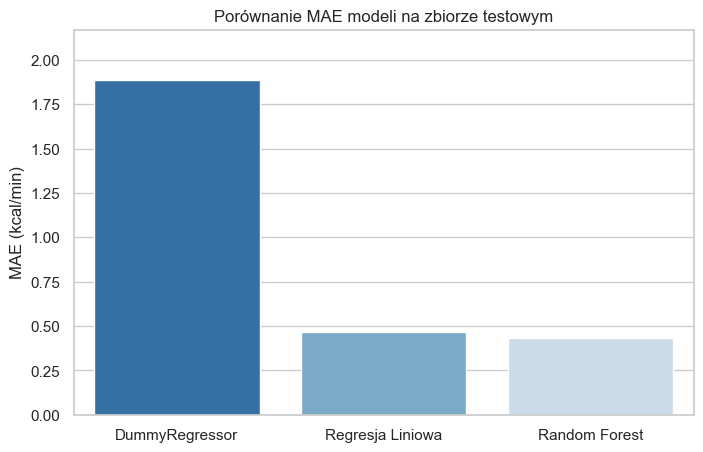

In [14]:
models = ['DummyRegressor', 'Regresja Liniowa', 'Random Forest']
mae_values = [mae_dummy, mae_lr, mae_rf]

plt.figure(figsize=(8, 5)) 
sns.barplot( 
    x=models, 
    y=mae_values, 
    hue=models,
    palette='Blues_r', 
    legend=False
)

plt.title('Porównanie MAE modeli na zbiorze testowym')
plt.ylabel('MAE (kcal/min)')
plt.ylim(0, max(mae_values) * 1.15)

plt.show()

### Wnioski z porównania modeli

- Baseline potwierdza istnienie struktury w danych.
- Regresja liniowa daje dużą poprawę i stabilne wyniki.
- Random Forest osiąga najlepszą jakość dzięki modelowaniu nieliniowości.

**Random Forest** pozostaje modelem docelowym ze względu na najwyższą dokładność i stabilność.

# Interpretacja cech modelu predykcyjnego

Po wyborze modelu docelowego (**Random Forest**) przeprowadzono analizę istotności cech w celu:
- identyfikacji kluczowych predyktorów `calories_per_min`,
- ocena spójności wyników,
- zwiększenie transparentności i interpretowalności modelu.

W analizie zastosowano dwa podejścia:

1. **Wbudowaną istotność** (impurity-based feature importance).
2. **Permutation importance** na zbiorze testowym.

Oba podejścia dostarczają innych perspektyw i wzajemnie się uzupełniają.

## Aspekt techniczny interpretacji cech w pipeline

Model działa w pipeline, dlatego:
- wbudowana istotność dotyczy **cech po transformacji**,
- zmienne kategoryczne są rozbite na wiele kolumn binarnych,
- permutation importance odnosi się do **oryginalnych kolumn wejściowych**.

### Ekstrakcja nazw cech po preprocessingu

In [15]:
# Dostęp do wytrenowanego modelu Random Forest z pipeline
rf_model = rf_pipeline.named_steps['model']

# Cechy numeryczne
feature_names_num = numeric_features

# Cechy kategoryczne
feature_names_cat = (
    rf_pipeline
    .named_steps['preproc']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features)
)

# Połączona lista cech
feature_names = np.concatenate([feature_names_num, feature_names_cat])
feature_names

array(['Distance', 'Avg HR', 'Max HR', 'Steps', 'Total Reps',
       'Total Poses', 'Stress Change', 'Avg Stress', 'day_of_week',
       'hour_sin', 'hour_cos', 'Activity Type_Cardio',
       'Activity Type_Strength Training', 'Activity Type_Walking',
       'Activity Type_Yoga'], dtype=object)

## Metody interpretacji cech

### Wbudowana istotność cech Random Forest

Istotność opiera się na łącznym spadku nieczystości w drzewach.

Cechy o najwyższej wartości *najczęściej uczestniczą w podziałach* oraz *najbardziej redukują błąd*.

Ograniczenie: metoda może faworyzować cechy z większą liczbą możliwych podziałów (np. po one-hot encoding).

In [16]:
# Pobranie istotności cech
importances = rf_model.feature_importances_

# DataFrame z wynikami
fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

fi_df.head(15)

,feature,importance
1,Avg HR,0.960227
2,Max HR,0.010872
8,day_of_week,0.005783
9,hour_sin,0.004909
10,hour_cos,0.004102
11,Activity Type_Cardio,0.002709
7,Avg Stress,0.002247
0,Distance,0.002200
13,Activity Type_Walking,0.001818
6,Stress Change,0.001591


### Permutation importance

Metoda polega na przetasowaniu jednej cechy i pomiarze spadku jakości (tu: wzrost MAE).

Zalety:
- ocena na zbiorze testowym (generalizacja),
- niezależność od struktury modelu,
- interpretacja na poziomie oryginalnych cech,
- większa odporność na artefakty one-hot encoding.

In [17]:
perm = permutation_importance(
    rf_pipeline,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring='neg_mean_absolute_error'
)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

perm_df.head(15)

,feature,importance_mean,importance_std
2,Avg HR,2.276691,0.101397
0,Activity Type,0.098685,0.021084
3,Max HR,0.022597,0.006923
10,hour_sin,0.011213,0.006739
1,Distance,0.008660,0.002813
11,hour_cos,0.007962,0.004178
4,Steps,0.005511,0.001523
5,Total Reps,0.001796,0.000671
8,Avg Stress,0.001125,0.002027
6,Total Poses,0.000753,0.000774


## Wnioski z analizy istotności cech

- `Avg HR` jest zdecydowanie najważniejszym predyktorem intensywności treningu.
- Wyniki obu metod są spójne, co zwiększa wiarygodność interpretacji.
- Pozostałe cechy pełnią rolę pomocniczą i mają znacznie mniejszy wkład.

Dominacja `Avg HR` jest zgodna z fizjologiczną interpretacją intensywności wysiłku.

# Analiza błędów modelu predykcyjnego

Celem jest ocena **dla jakich obserwacji model popełnia  błędy** oraz czy mają one charakter systematyczny.

Analiza pozwala:
- ocenić zgodność predykcji z wartościami rzeczywistymi,
- zbadać rozkład reszt i ich zależność od poziomu intensywności,
- sprawdzić, czy model popełnia większe błędy dla określonych typów aktywności.

In [18]:
# Predykcje modelu Random Forest na zbiorze testowym
y_pred = rf_pipeline.predict(X_test)

# DataFrame do analizy błędów
errors_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred,
    'residual': y_test - y_pred,
    'Activity Type': X_test['Activity Type'].values
})

print(errors_df.head())

        y_true     y_pred  residual Activity Type
753   3.892562   3.742844  0.149718          Yoga
364  10.419907  10.181894  0.238013        Cardio
756   5.723370   5.584299  0.139071          Yoga
652   4.718101   4.712927  0.005174          Yoga
452   6.158631   6.596151 -0.437520          Yoga


## Predykcja vs wartości rzeczywiste

Wykres `y_true vs y_pred` pozwala ocenić dopasowanie modelu.

Punkty skupione wokół linii 45° oznaczają dobrą jakość predykcji.

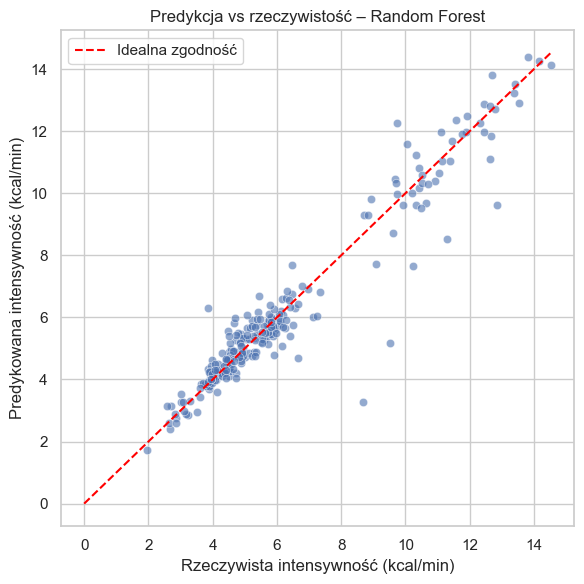

In [19]:
plt.figure(figsize=(6, 6))
sns.scatterplot(
    x=errors_df['y_true'],
    y=errors_df['y_pred'],
    alpha=0.6
)
plt.plot(
    [0, errors_df['y_true'].max()],
    [0, errors_df['y_true'].max()],
    color='red',
    linestyle='--',
    label='Idealna zgodność'
)
plt.xlabel('Rzeczywista intensywność (kcal/min)')
plt.ylabel('Predykowana intensywność (kcal/min)')
plt.title('Predykcja vs rzeczywistość – Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

## Analiza reszt (residuals)

W idealnym scenariuszu reszty powinny być:
- rozproszone losowo wokół 0,
- bez trendu względem `y_pred`,
- bez efektu „lejka” (heteroskedastyczności).

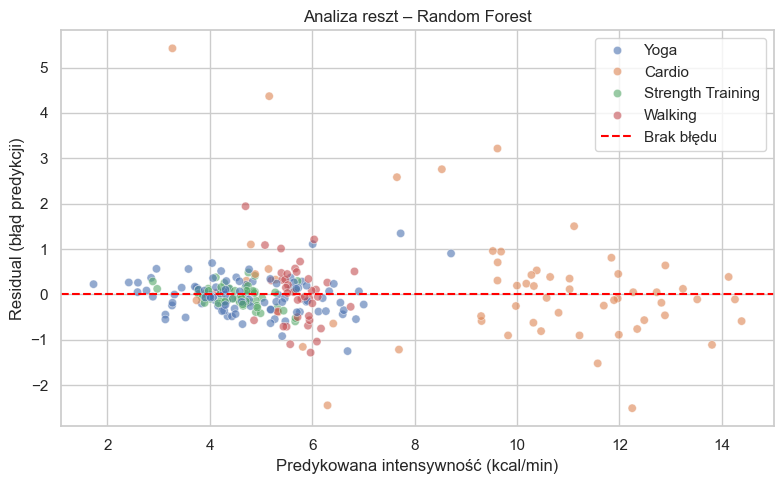

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot( 
    data=errors_df, 
    x='y_pred', 
    y='residual', 
    hue='Activity Type', 
    alpha=0.6 
)
plt.axhline(0, color='red', linestyle='--', label='Brak błędu')
plt.xlabel('Predykowana intensywność (kcal/min)')
plt.ylabel('Residual (błąd predykcji)')
plt.title('Analiza reszt – Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

## Błędy per typ aktywności

Przeanalizowano statystyki reszt w podziale na `Activity Type`, aby sprawdzić, czy model różni się jakością predykcji między rodzajami treningów.

Porównano średnią, medianę oraz odchylenie standardowe błędów w każdej kategorii.

In [21]:
errors_by_activity = errors_df.groupby('Activity Type')['residual'].agg(['mean', 'std', 'median', 'count'])
errors_by_activity

,mean,std,median,count
Activity Type,,,,
Cardio,0.172500,1.347584,0.048860,59
Strength Training,-0.037654,0.223395,-0.062193,54
Walking,0.026342,0.655069,0.032553,41
Yoga,-0.031197,0.388020,-0.047871,100


## Wnioski z analizy błędów

- Predykcje są bliskie wartościom rzeczywistym (zgodność z linią idealną).
- Reszty są rozproszone wokół zera — brak systematycznego przeszacowania lub niedoszacowania.
- Nie obserwuje się wyraźnego trendu systematycznego w funkcji poziomu intensywności, choć dla wysokich wartości (głównie `Cardio`) widoczny jest większy rozrzut błędów.
- Model zachowuje porównywalną jakość dla różnych typów aktywności, przy większej zmienności w `Cardio`.
- Pojedyncze większe błędy mają charakter incydentalny i nie tworzą spójnego wzorca.

Wyniki te wskazują, że model nie tylko osiąga wysoką jakość globalną (MAE, R²), ale również **zachowuje stabilność na poziomie indywidualnych obserwacji**.

# Zapis wytrenowanego modelu i pipeline’u

Wytrenowany **pipeline (preprocessing + Random Forest)** zapisano w celu jego ponownego użycia poza notebookiem. Zapis całej struktury gwarantuje spójność transformacji oraz pełną replikowalność predykcji.

Do zapisu wykorzystano `joblib`.

In [22]:
# Ścieżka do katalogu głównego projektu (notebook w podkatalogu, np. notebooks/)
project_root = os.path.abspath('..')

# Katalog na modele w katalogu głównym
models_dir = os.path.join(project_root, 'models')
os.makedirs(models_dir, exist_ok=True)

# Zapis pipeline’u
joblib.dump(rf_pipeline, os.path.join(models_dir, 'random_forest_pipeline.joblib'))

# Zapis metadanych
metadata = {
    'python_version': sys.version,
    'sklearn_version': __import__('sklearn').__version__,
    'model_type': 'RandomForestRegressor',
    'description': 'Pipeline: preprocessing + Random Forest do predykcji calories_per_min'
}
joblib.dump(metadata, os.path.join(models_dir, 'model_metadata.joblib'))

print(f"Model i metadane zapisane w katalogu '{models_dir}'.")

Model i metadane zapisane w katalogu 'C:\Users\micha\PycharmProjects\training-intensity-prediction\models'.


## Uwagi dotyczące replikowalności

- Zapisano kompletny pipeline (preprocessing + model), co eliminuje ryzyko niespójnych transformacji przy ponownym użyciu.
- Artefakty umieszczono w katalogu models/, oddzielając je od kodu eksperymentalnego.
- Dodatkowo zapisano metadane (wersje środowiska i opis modelu), co umożliwia odtworzenie warunków trenowania.

# Podsumowanie modelowania i wdrożenia modelu predykcyjnego

W notebooku zrealizowano pełny proces modelowania predykcyjnego intensywności treningu (`calories_per_min`): od budowy pipeline’u, przez ewaluację i interpretację, po zapis modelu do wykorzystania.

## Kluczowe wyniki 

- **Regresja liniowa (model referencyjny)**: MAE ≈ 0.46, R² ≈ 0.91 – potwierdza silny sygnał predykcyjny w danych.
- **Random Forest (model docelowy)**: MAE ≈ 0.43, R² ≈ 0.93 – najlepsza jakość predykcji oraz stabilne wyniki w walidacji krzyżowej.
- **Interpretacja cech**: Średnie tętno (`Avg HR`) jest dominującym predyktorem intensywności (pozostałe zmienne mają wpływ jedynie pomocniczy, co jest zgodne z wiedzą fizjologiczną).
- **Analiza błędów**: Brak systematycznych odchyleń, reszty rozproszone wokół zera (większa zmienność dla Cardio wynika z charakteru tej aktywności, nie z błędu strukturalnego modelu).

Model wykazuje dobrą generalizację i nie zdradza oznak przeuczenia.

## Wdrożenie modelu

Zapisano kompletny pipeline (preprocessing + model) w katalogu `models/` wraz z metadanymi środowiska. Zapewnia to:
- spójność transformacji przy inferencji,
- możliwość wykorzystania modelu poza notebookiem,
- odtwarzalność eksperymentu.

Na tej podstawie przygotowano **API (FastAPI)** umożliwiające wykonywanie predykcji.

---

**Random Forest** stanowi stabilny i praktyczny model predykcyjny, gotowy do dalszej integracji z systemem analitycznym.